# initial analysis

In [1]:
import warnings
warnings.filterwarnings('ignore')
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "utils")))
from analysis_utils import (
    volcano_plot_br,
    plot_spatial_clusters_per_sample,
    plot_dotplot_by_treatment,
    plot_relative_cluster_composition
)
import scanpy as sc
import numpy as np

import scanpy as sc
import matplotlib.pyplot as plt
plaque_induced_genes = [
    "Apoe", "Clu", "Ctsd", "C1qa", "C1qb", "C1qc", "C4b", "Tyrobp", "Trem2", "Cst7",
    "Fcer1g", "Axl", "Lilrb4", "Lpl", "Csf1", "Csf1r", "Cst3", "Ctsb", "Gpnmb", "Hexb",
    "Lyz2", "Slc2a5", "Serpina3n", "Lgals3", "Itgax", "C3"
]

In [2]:
ad = sc.read_h5ad('../data/ST_BRICHOS.h5ad')

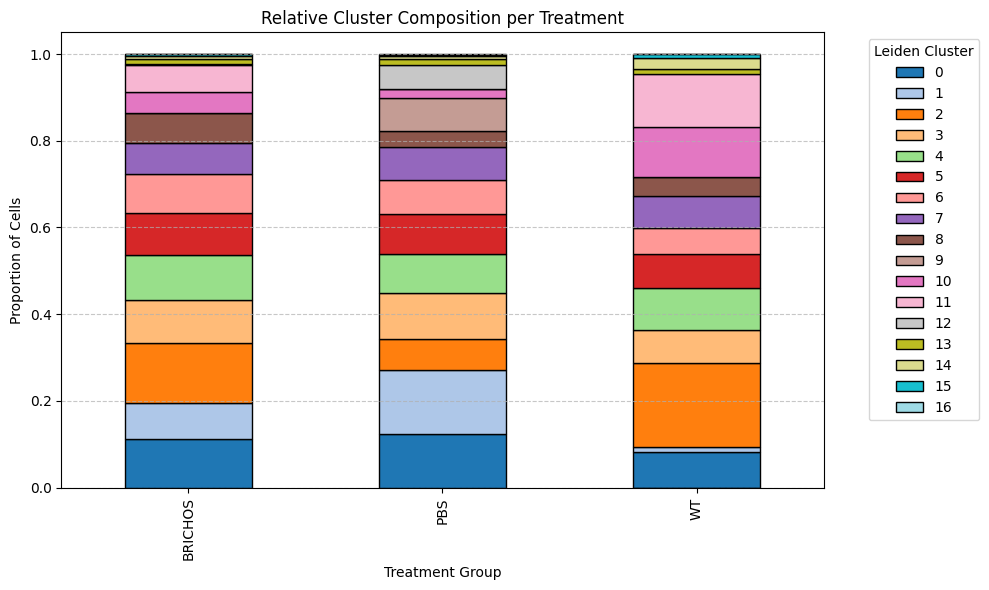

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Compute relative distribution
cluster_distribution = pd.crosstab(ad.obs["treatment"], ad.obs["leiden"])
relative_distribution = cluster_distribution.div(cluster_distribution.sum(axis=1), axis=0)

# Plot
ax = relative_distribution.plot(
    kind="bar", 
    stacked=True, 
    figsize=(10, 6), 
    colormap="tab20",  # Or try "viridis", "Set3", etc.
    edgecolor="black"
)

plt.title("Relative Cluster Composition per Treatment")
plt.ylabel("Proportion of Cells")
plt.xlabel("Treatment Group")
plt.legend(title="Leiden Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

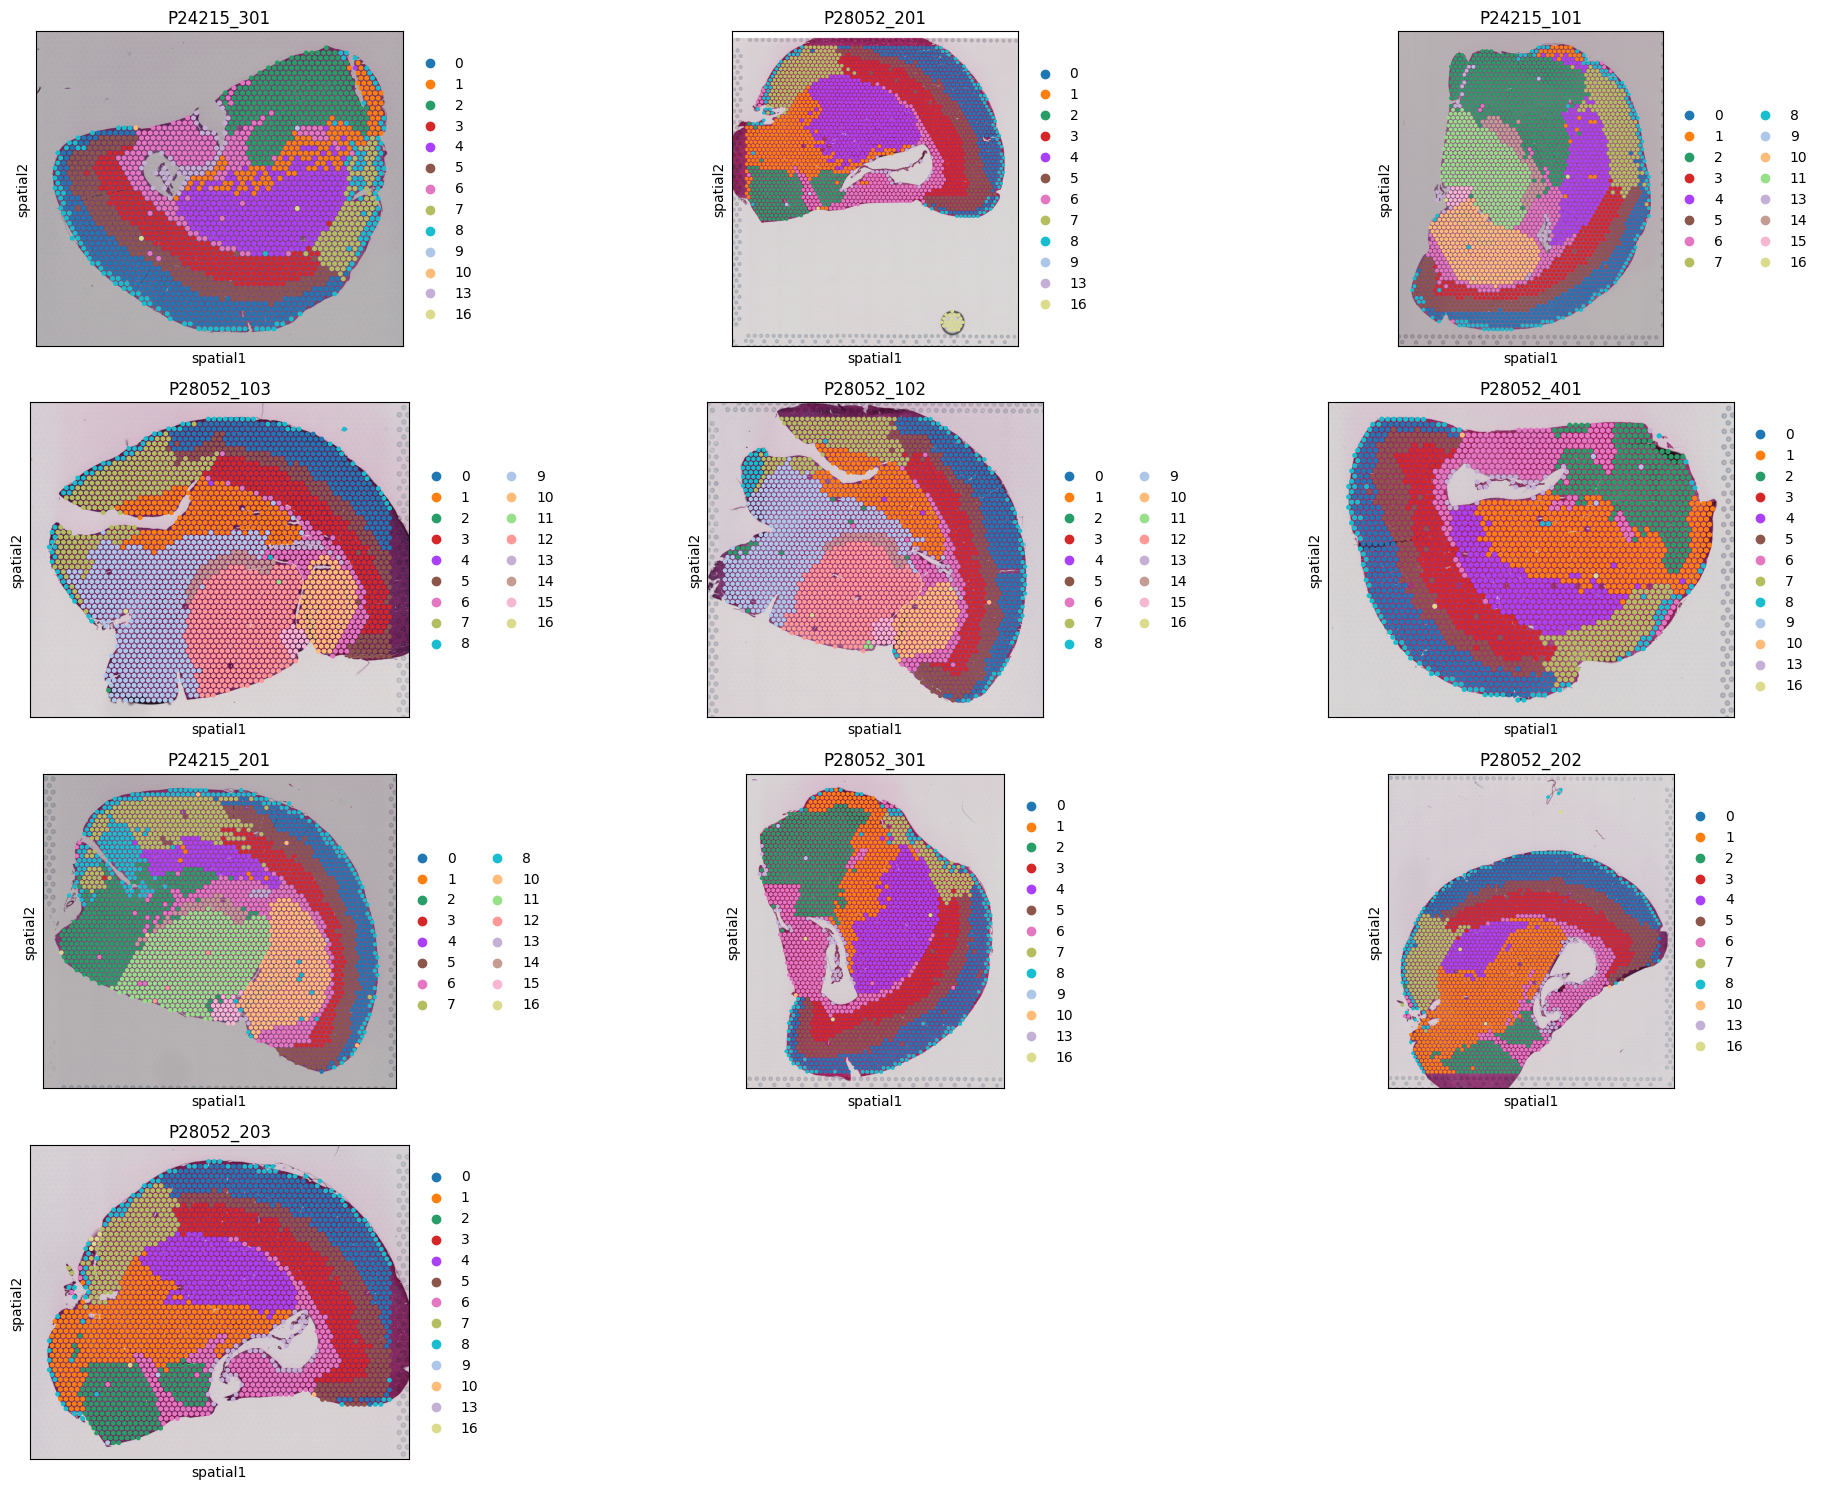

In [4]:
plot_spatial_clusters_per_sample(ad, color = 'leiden', figsize=(20,15))

In [5]:
sc.tl.rank_genes_groups(ad, groupby='leiden', method='wilcoxon')

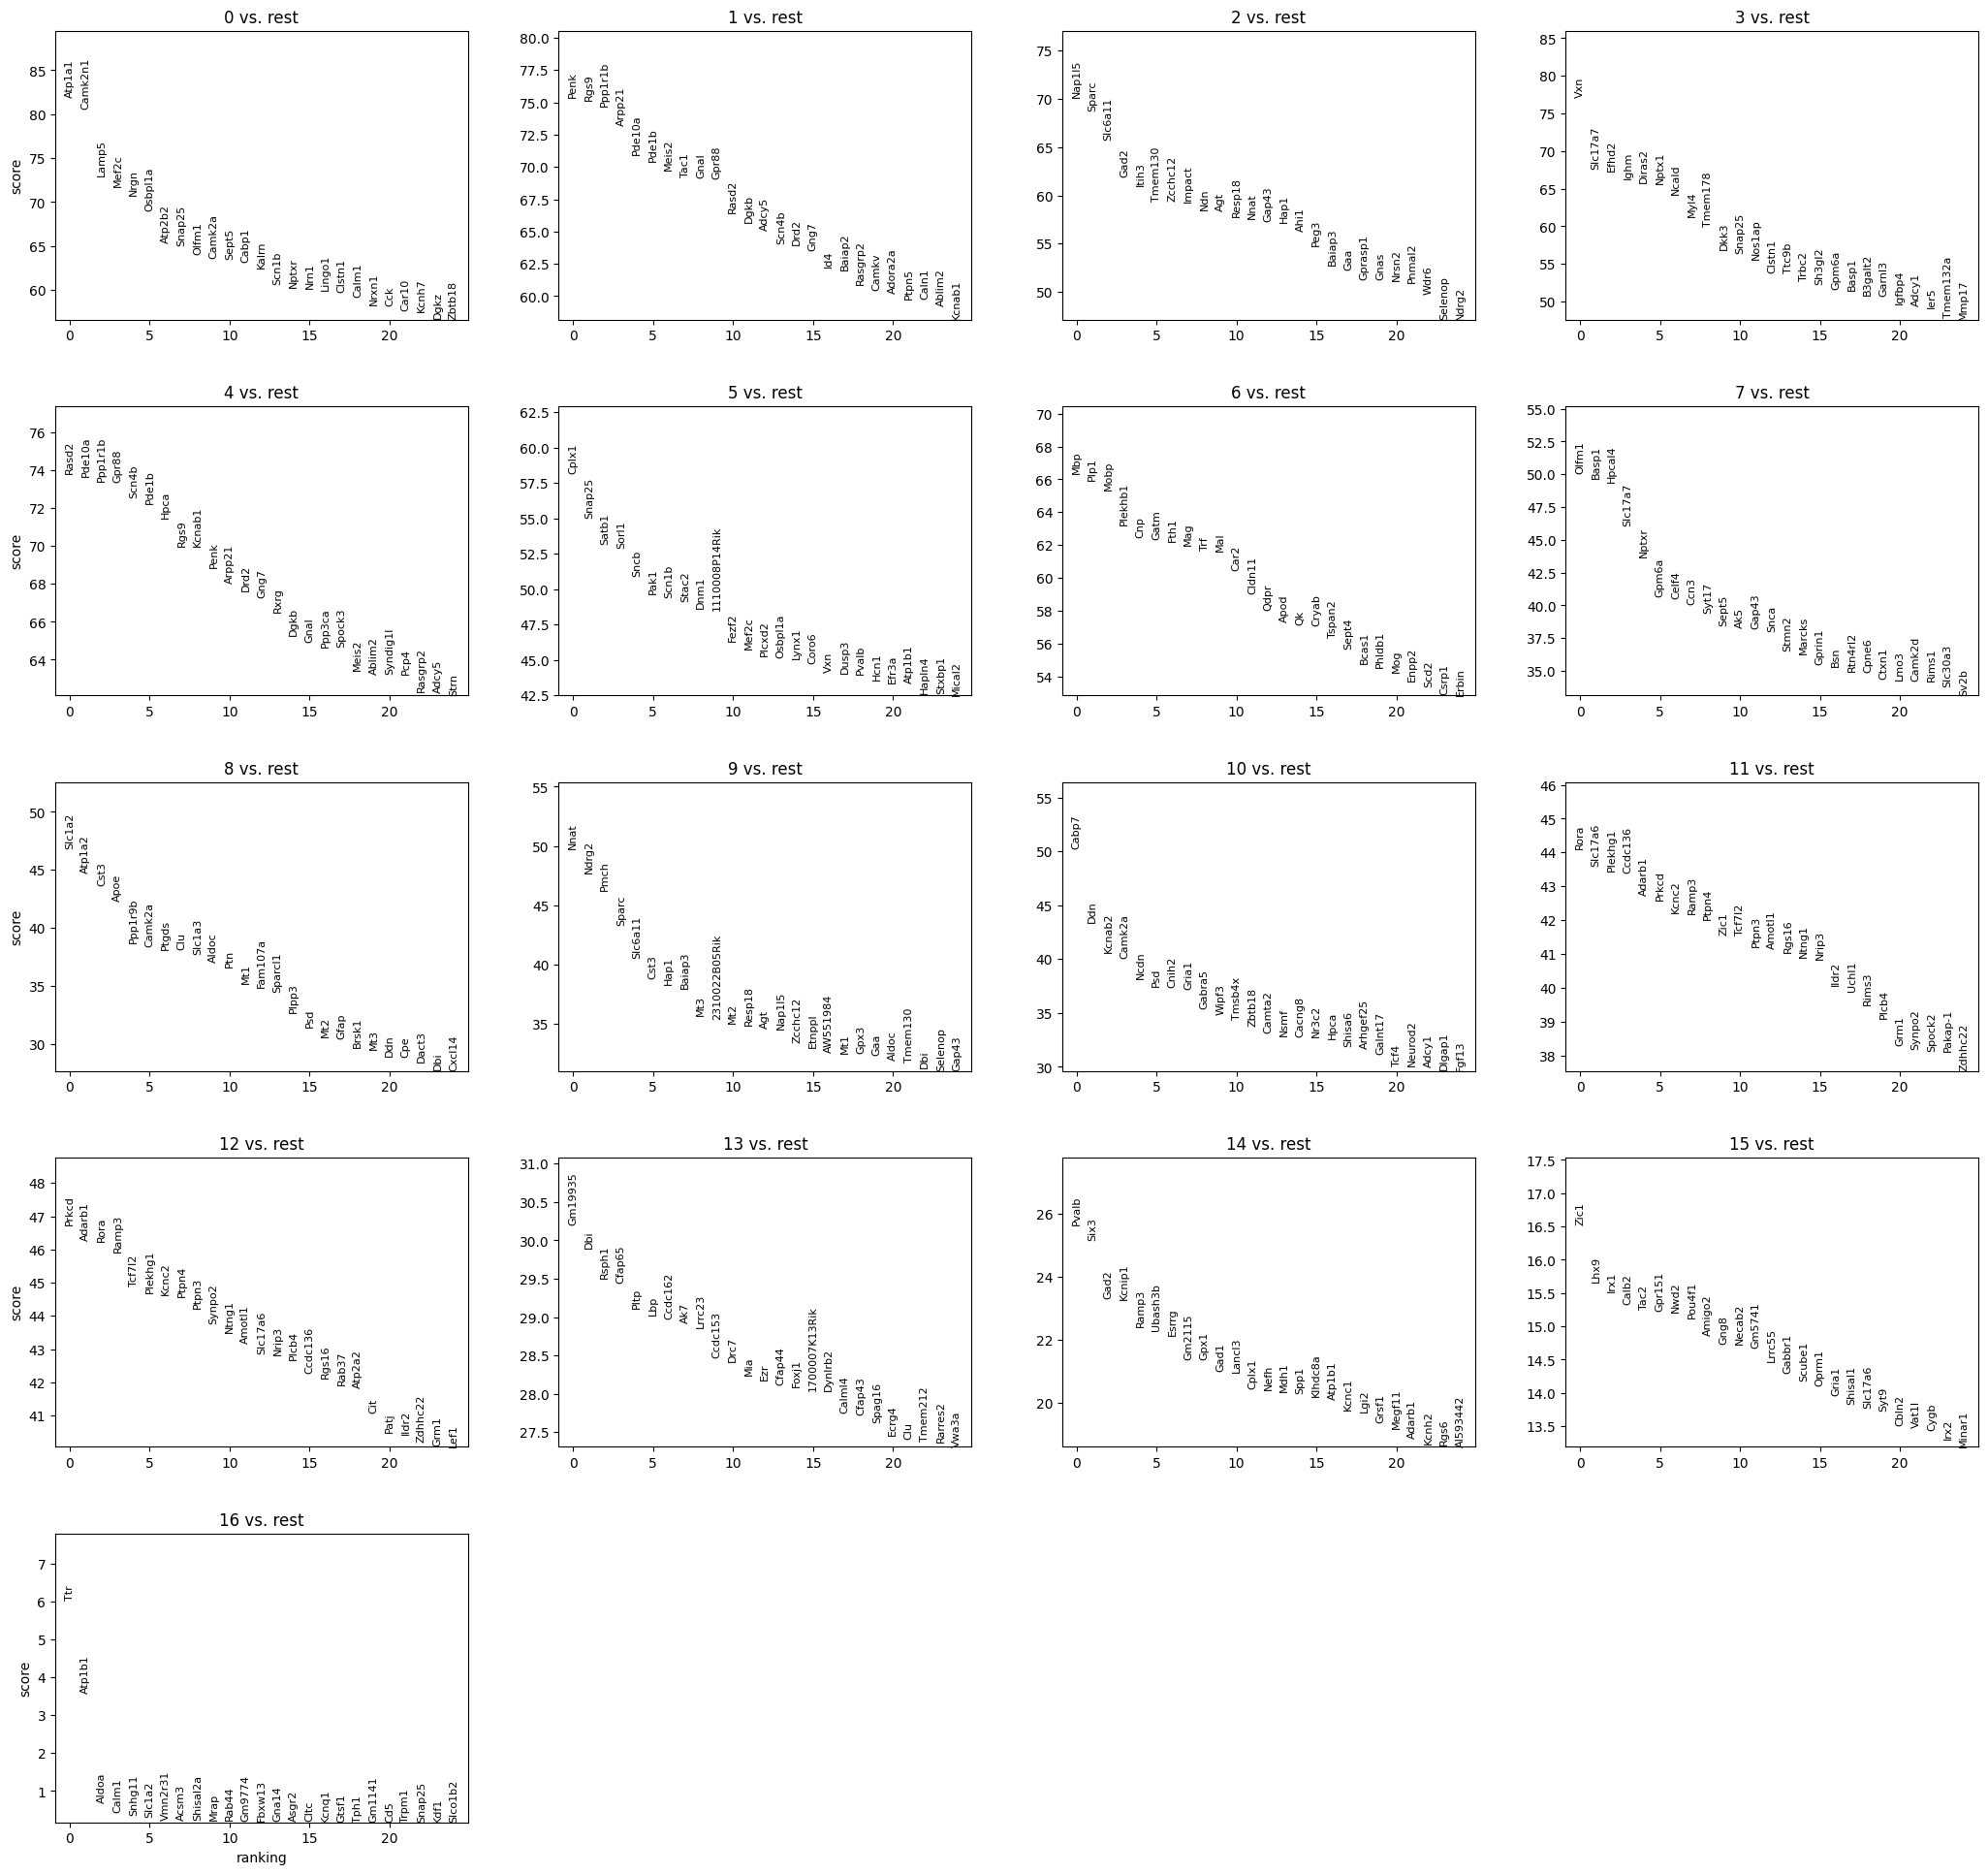

In [6]:
# See top 5 marker genes per cluster
sc.pl.rank_genes_groups(ad, n_genes=25, sharey=False)

# Comparing DE genes between the treatments

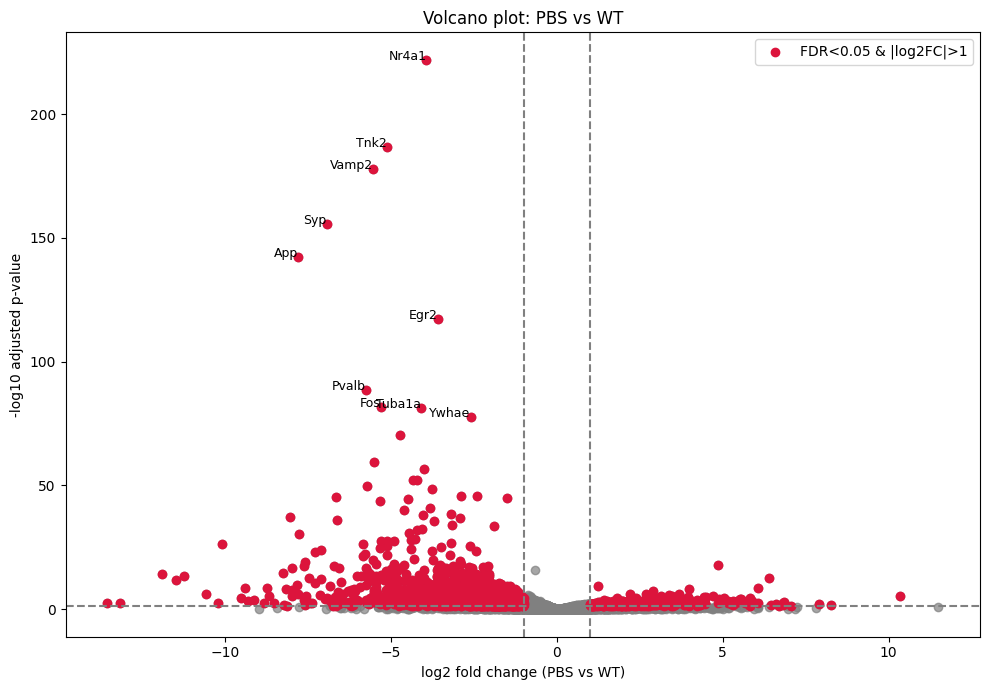

In [7]:
volcano_plot_br(ad, groupby='treatment',
    group1='PBS',
    group2='WT')

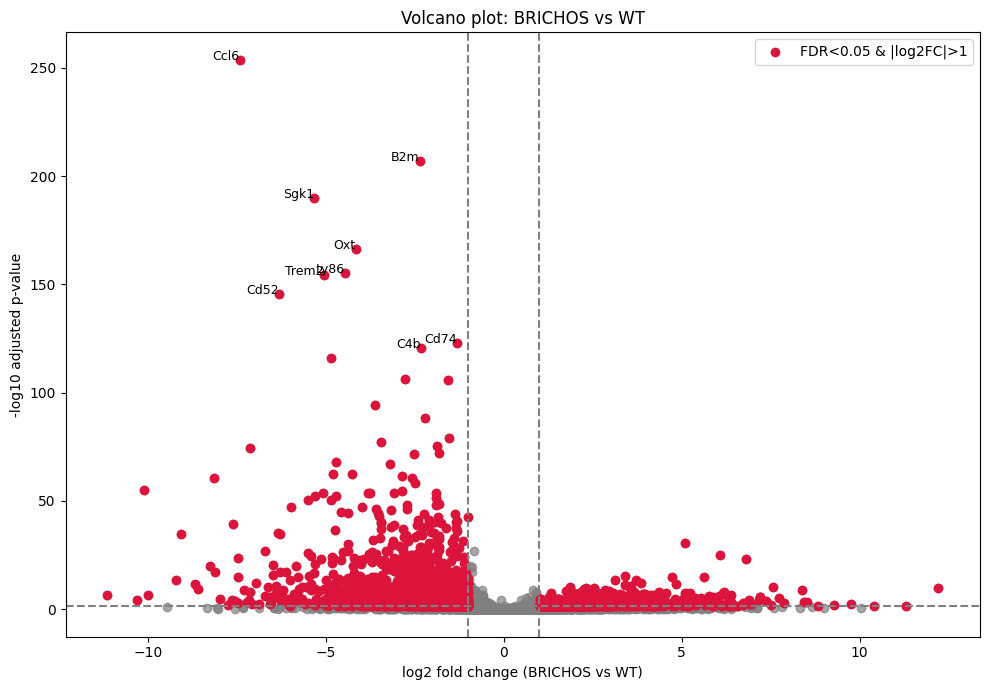

In [8]:
volcano_plot_br(ad, groupby='treatment',
    group1='BRICHOS',
    group2='WT')

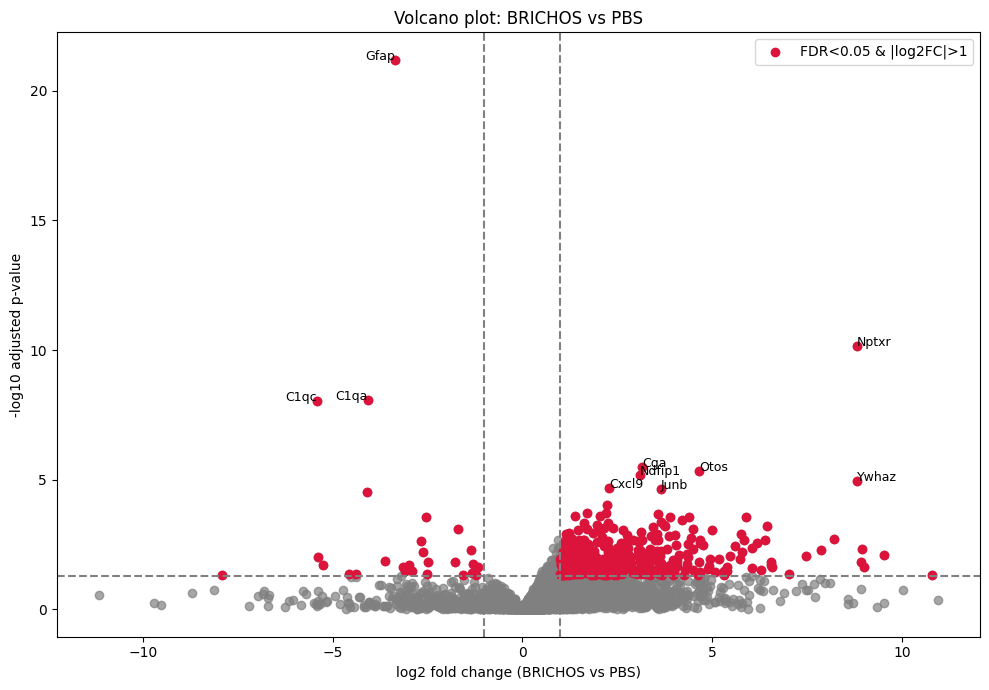

In [9]:
volcano_plot_br(ad, groupby='treatment',
    group1='BRICHOS',
    group2='PBS')

# Plaque-Induced Gene Expression by Treatment Group

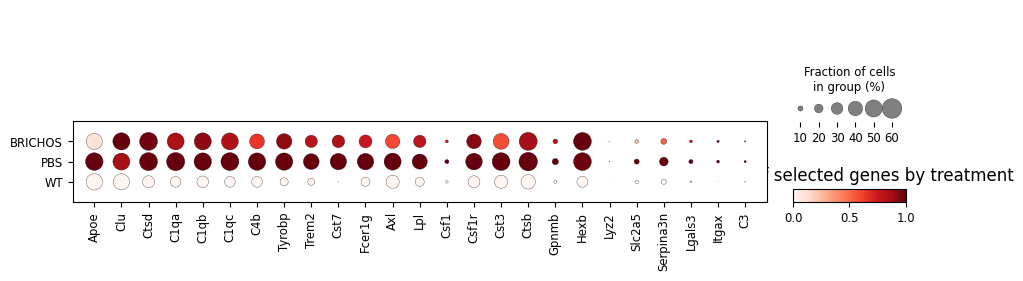

In [10]:
plaque_induced_genes = [
    "Apoe", "Clu", "Ctsd", "C1qa", "C1qb", "C1qc", "C4b", "Tyrobp", "Trem2",
    "Cst7", "Fcer1g", "Axl", "Lpl", "Csf1", "Csf1r", "Cst3",
    "Ctsb", "Gpnmb", "Hexb", "Lyz2", "Slc2a5", "Serpina3n", "Lgals3", "Itgax", "C3"
]

plot_dotplot_by_treatment(ad, genes=plaque_induced_genes)

In [13]:
sc.tl.score_genes(ad, gene_list=plaque_induced_genes, score_name='plaque_score')

In [14]:
from scipy.stats import mannwhitneyu

group1 = ad.obs[ad.obs["treatment"] == "PBS"]["plaque_score"].dropna()
group2 = ad.obs[ad.obs["treatment"] == "WT"]["plaque_score"].dropna()

stat, pval = mannwhitneyu(group1, group2)
print(f"📊 Mann–Whitney U test p-value: {pval:.4e}")

📊 Mann–Whitney U test p-value: 0.0000e+00


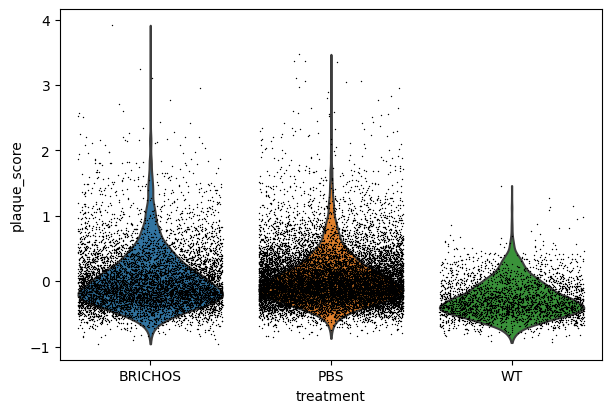

In [15]:
# Plot module score by treatment group
sc.pl.violin(ad, keys="plaque_score", groupby="treatment", stripplot=True, jitter=0.4)


# 1. Baseline Gene Expression Analysis
Comparison of wild-type (WT) mice and APPNLGF non-treated mice to identify genes that are differentially expressed globally and in specific anatomical regions of the brain.  

In [16]:
# Subset to WT and APP PBS
ad_base = ad[ad.obs["treatment"].isin(["WT", "PBS"])].copy()

# Differential expression
sc.tl.rank_genes_groups(ad_base, groupby="treatment", method="wilcoxon", reference="WT")

# Extract results
de_wt_vs_pbs = sc.get.rank_genes_groups_df(ad_base, group="PBS")

In [17]:
de_wt_vs_pbs

,names,scores,logfoldchanges,pvals,pvals_adj
0,Gfap,54.275009,NaN,0.000000e+00,0.000000e+00
1,Cst7,41.822460,NaN,0.000000e+00,0.000000e+00
2,B2m,39.198086,NaN,0.000000e+00,0.000000e+00
3,C1qa,33.788212,NaN,2.938526e-250,7.871471e-247
4,Tyrobp,33.592270,NaN,2.175568e-247,5.099260e-244
...,...,...,...,...,...
18746,Eef1a2,-29.319330,NaN,5.881513e-189,5.804434e-186
18747,Prkar1b,-30.961960,NaN,1.753853e-210,1.934500e-207
18748,Map1b,-34.975876,NaN,5.236472e-268,1.636485e-264
18749,Faim2,-40.631584,NaN,0.000000e+00,0.000000e+00


# 2. Validation of AD-Related Genes 
Cross-referencing the identified differentially expressed genes in APPNLGF non-treated mice with published datasets on APP mouse models to determine which of these genes are directly associated with AD pathology.  

In [18]:
# Check if DE genes overlap
de_wt_vs_pbs["is_ad_related"] = de_wt_vs_pbs["names"].isin(plaque_induced_genes)

In [19]:
de_wt_vs_pbs.head(20)

,names,scores,logfoldchanges,pvals,pvals_adj,is_ad_related
0,Gfap,54.275009,NaN,0.000000e+00,0.000000e+00,False
1,Cst7,41.822460,NaN,0.000000e+00,0.000000e+00,True
2,B2m,39.198086,NaN,0.000000e+00,0.000000e+00,False
3,C1qa,33.788212,NaN,2.938526e-250,7.871471e-247,True
4,Tyrobp,33.592270,NaN,2.175568e-247,5.099260e-244,True
5,Mt2,33.445057,NaN,3.036893e-245,6.327197e-242,False
6,Cd74,33.005737,NaN,6.720255e-239,1.260115e-235,False
7,C1qc,32.689919,NaN,2.172110e-234,3.702657e-231,True
8,Arc,32.506016,NaN,8.767247e-232,1.369955e-228,False
9,Hexb,31.682011,NaN,2.749059e-220,3.965200e-217,True


# 3. BRICHOS Treatment Effect
Comparison of APP non-treated mice and APP BRICHOS-treated mice to identify genes modulated by BRICHOS treatment, both globally and within distinct brain regions.  

In [20]:
ad_br = ad[ad.obs["treatment"].isin(["PBS", "BRICHOS"])].copy()
sc.tl.rank_genes_groups(ad_br, groupby="treatment", method="t-test_overestim_var", reference="PBS")
de_br_vs_pbs = sc.get.rank_genes_groups_df(ad_br, group="BRICHOS")

In [21]:
de_br_vs_pbs

,names,scores,logfoldchanges,pvals,pvals_adj
0,Syt1,34.367989,NaN,4.436187e-249,8.318295e-245
1,Faim2,33.957104,NaN,1.440116e-243,1.350181e-239
2,Egr1,30.333099,NaN,8.675271e-196,4.066750e-192
3,Pfn2,28.912699,NaN,6.026663e-179,2.260119e-175
4,Lrp1,24.283989,NaN,1.065683e-127,2.854661e-124
...,...,...,...,...,...
18746,Hnrnpu,-20.859863,NaN,3.055732e-95,4.092717e-92
18747,Ckb,-22.511700,NaN,2.539647e-110,4.329174e-107
18748,Stmn1,-23.196981,NaN,5.627149e-117,1.055147e-113
18749,Cox6c,-24.503637,NaN,6.300857e-130,1.969123e-126


# 4. Linking BRICHOS Effects to AD Pathology
Comparison of genes affected by BRICHOS treatment with the validated AD-related genes to identify which aspects of AD pathology are modulated by BRICHOS.  

In [22]:
# Compare BRICHOS DE genes to AD-related ones
de_br_vs_pbs["is_ad_related"] = de_br_vs_pbs["names"].isin(plaque_induced_genes)

# Find overlapping gene names
common_ad_modulated = set(de_br_vs_pbs.loc[de_br_vs_pbs["is_ad_related"], "names"]) & set(de_wt_vs_pbs["names"])
print(f"🧬 Genes modulated by BRICHOS and linked to AD pathology: {common_ad_modulated}")

🧬 Genes modulated by BRICHOS and linked to AD pathology: {'Fcer1g', 'Axl', 'Lpl', 'C1qc', 'Csf1', 'Trem2', 'C4b', 'Apoe', 'Cst3', 'Serpina3n', 'Itgax', 'Tyrobp', 'Ctsb', 'Hexb', 'Slc2a5', 'Gpnmb', 'C3', 'Cst7', 'Lyz2', 'Lgals3', 'Clu', 'C1qb', 'Ctsd', 'Csf1r', 'C1qa'}
